# When Dropping PCM Samples Creates a New Sound
## A 64 kHz → 32 kHz experiment for embedded developers

A digital microphone can deliver correct PCM values while firmware changes the information those values represent. This notebook demonstrates that difference with **synthetic audio**, then fixes the downsampling path with a low-pass filter.

The experiment has three paths: original 64 kHz PCM, unfiltered 32 kHz PCM, and low-pass-filtered 32 kHz PCM. Each step includes runnable code and its output.

**Question:** If we keep one sample and discard the next, then play the result at half the original rate, is the sound preserved?

**Prediction:** The 3 and 10 kHz tones remain at their original frequencies. A 31 kHz tone aliases to 1 kHz unless it is sufficiently attenuated before samples are discarded.

Run all cells from top to bottom using the project's virtual environment. Audio widgets are embedded in the executed notebook and HTML export. Start playback at low volume.

## 1. Input overview — listen to the original

We construct a four-second, mono PCM16 signal sampled at **64,000 samples/second**:

$$
x[n]=0.12\cos(2\pi 3000n/64000)+0.12\cos(2\pi 10000n/64000)+0.12\cos(2\pi 31000n/64000)
$$

| Parameter | Value |
|---|---|
| Sample rate | 64 kHz |
| Nyquist frequency | 32 kHz |
| Components | 3, 10, 31 kHz |
| Peak amplitude per component | 0.12 full scale |
| Duration | 4 seconds |
| Encoding | Mono, signed 16-bit PCM |

All three tones are below the original Nyquist limit. A 10 ms fade at each endpoint reduces start/stop clicks; it is not an anti-alias filter.

The 31 kHz tone is deliberately synthetic. Ordinary speakers will not reproduce it faithfully, and a browser or OS may resample playback. We establish its presence from the saved PCM and FFT, rather than claiming it can be heard directly.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import hashlib
import wave

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, Markdown, display

# Locate the project whether Jupyter starts in the root or notebooks directory.
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for base in candidates for p in (base, base / "2_downsample")
             if (p / "code" / "01_pcm_aliasing_walkthrough.ipynb").is_file()), None)
if ROOT is None:
    raise RuntimeError("Start Jupyter inside the PCM Aliasing Lab repository.")

INPUT = ROOT / "input"
INPUT.mkdir(parents=True, exist_ok=True)
OUT = ROOT / "output"
OUT.mkdir(parents=True, exist_ok=True)

FS_IN = 64_000
FS_OUT = 32_000
DURATION = 4
TONES_HZ = (3_000, 10_000, 31_000)
AMPLITUDE = 0.12

def save_pcm16(path, pcm, sample_rate):
    with wave.open(str(path), "wb") as wav:
        wav.setnchannels(1)
        wav.setsampwidth(2)
        wav.setframerate(sample_rate)
        wav.writeframes(np.asarray(pcm, dtype="<i2").tobytes())

def load_pcm16(path):
    with wave.open(str(path), "rb") as wav:
        sample_rate = wav.getframerate()
        pcm = np.frombuffer(wav.readframes(wav.getnframes()), dtype="<i2").copy()
    return pcm, sample_rate

# All players use the same PCM scaling: no per-recording loudness normalization.
def listen(pcm, sample_rate):
    display(Audio(pcm.astype(np.float64) / 32767,
                  rate=sample_rate, normalize=False))

In [2]:
t = np.arange(FS_IN * DURATION) / FS_IN
signal = sum(AMPLITUDE * np.cos(2 * np.pi * f * t) for f in TONES_HZ)

fade_length = int(0.010 * FS_IN)
fade = np.linspace(0.0, 1.0, fade_length)
signal[:fade_length] *= fade
signal[-fade_length:] *= fade[::-1]

original_pcm = np.rint(signal * 32767).astype(np.int16)
save_pcm16(INPUT / "before_64khz.wav", original_pcm, FS_IN)
original_pcm, original_rate = load_pcm16(INPUT / "before_64khz.wav")

print(f"Input: {len(original_pcm):,} samples at {original_rate:,} Hz")
print(f"Duration: {len(original_pcm) / original_rate:.1f} seconds")
print("Listen to the original; its 31 kHz component is verified later by FFT.")
listen(original_pcm, original_rate)

Input: 256,000 samples at 64,000 Hz
Duration: 4.0 seconds
Listen to the original; its 31 kHz component is verified later by FFT.


## 2. Downsample only — listen again

We retain every other sample:

$$
y[m]=x[2m]
$$

The output contains half as many samples and is played at **32 kHz**, not 64 kHz. Its duration remains four seconds, so this is not a demonstration of playing the recording twice as fast.

However, the new Nyquist limit is **16 kHz**. Correct playback metadata does not prevent a component above that limit from aliasing.

Listen for the new low-frequency tone. It comes from the 31 kHz component, not from data corruption on the digital interface.

In [3]:
unfiltered_pcm = original_pcm[::2].copy()  # No low-pass filter.
save_pcm16(OUT / "after_32khz_unfiltered.wav", unfiltered_pcm, FS_OUT)
unfiltered_pcm, unfiltered_rate = load_pcm16(OUT / "after_32khz_unfiltered.wav")

assert np.array_equal(unfiltered_pcm, original_pcm[::2])
assert len(unfiltered_pcm) / unfiltered_rate == DURATION

print(f"Output: {len(unfiltered_pcm):,} samples at {unfiltered_rate:,} Hz")
print(f"Duration: {len(unfiltered_pcm) / unfiltered_rate:.1f} seconds")
listen(unfiltered_pcm, unfiltered_rate)

Output: 128,000 samples at 32,000 Hz
Duration: 4.0 seconds


## 3. FFT analysis of the original 64 kHz audio

The FFT answers: **which frequencies are present in the saved PCM?**

We analyze the middle two seconds, excluding the endpoint fades. Each test tone completes an integer number of cycles in that interval, so a rectangular analysis window is appropriate here. Real microphone recordings usually need a deliberate window choice to control spectral leakage.

Frequency-bin spacing is $1/T=0.5$ Hz. We normalize the one-sided FFT by the number of samples, doubling non-DC/non-Nyquist bins. Thus a cosine with peak amplitude 0.12 produces a spectral peak near 0.12 FS.

The waveform view shows one millisecond with actual sample markers. Connecting lines help visualize the samples; they are not an analog reconstruction.

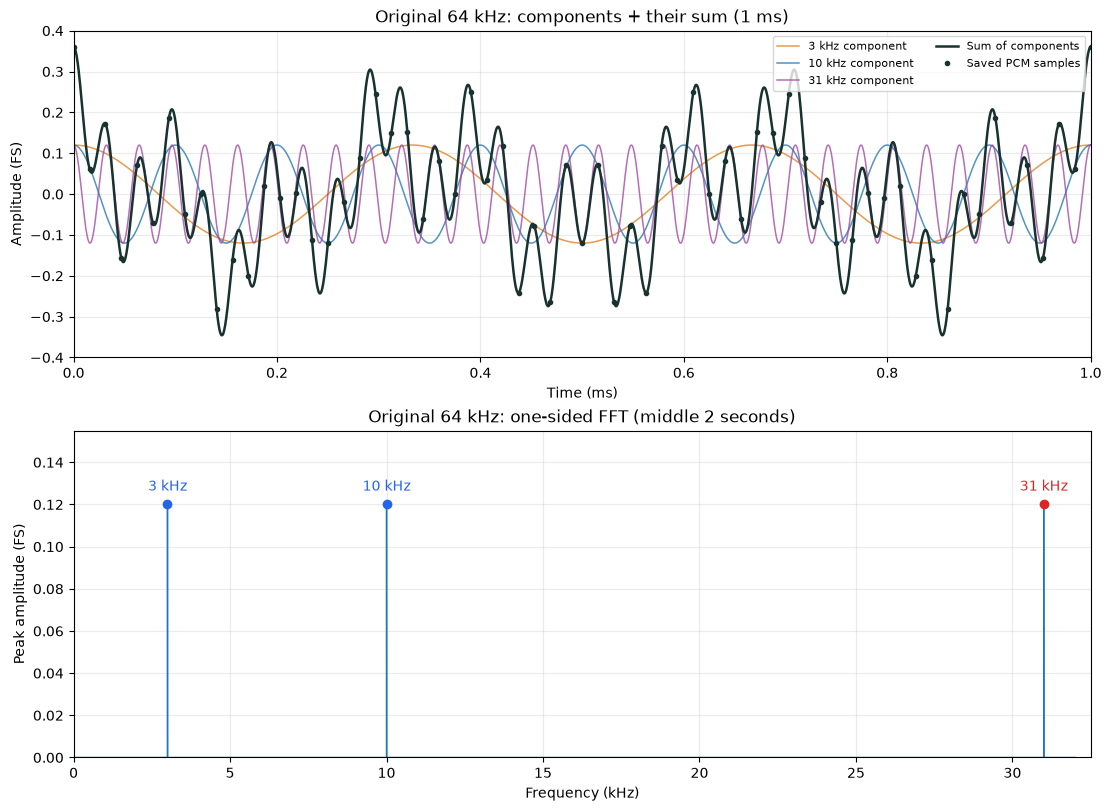

Three strongest FFT bins: [np.float64(3000.0), np.float64(10000.0), np.float64(31000.0)]
Original 1 kHz amplitude: 0.00000041 FS


In [4]:
def one_sided_fft(pcm, sample_rate):
    segment = pcm[sample_rate:3 * sample_rate].astype(np.float64) / 32767
    frequencies = np.fft.rfftfreq(len(segment), d=1 / sample_rate)
    amplitudes = np.abs(np.fft.rfft(segment)) / len(segment)
    amplitudes[1:] *= 2
    if len(segment) % 2 == 0:
        amplitudes[-1] /= 2  # The Nyquist bin is not doubled.
    return frequencies, amplitudes

def amplitude_at(pcm, sample_rate, frequency_hz):
    frequencies, amplitudes = one_sided_fft(pcm, sample_rate)
    index = np.argmin(np.abs(frequencies - frequency_hz))
    return float(amplitudes[index])

def show_waveform_and_fft(pcm, sample_rate, label, marked_hz, image_name):
    frequencies, amplitudes = one_sided_fft(pcm, sample_rate)
    start = sample_rate
    count = sample_rate // 1000 + 1
    time_ms = np.arange(count) / sample_rate * 1000

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)
    # Fit coherent tone components to saved PCM, preserving measured phase/gain.
    segment = pcm[sample_rate:3 * sample_rate].astype(float) / 32767
    fit_time = np.arange(len(segment)) / sample_rate + 1
    smooth_ms = np.linspace(0, 1, 2001)
    smooth_time = smooth_ms / 1000 + 1
    fitted_sum = np.zeros_like(smooth_time)
    sampled_sum = np.zeros(count)
    for frequency_hz in marked_hz:
        color = {3000: "#e18221", 10000: "#2878b5"}.get(frequency_hz, "#a24ba4")
        cosine = 2 * np.mean(segment * np.cos(2*np.pi*frequency_hz*fit_time))
        sine = 2 * np.mean(segment * np.sin(2*np.pi*frequency_hz*fit_time))
        component = cosine*np.cos(2*np.pi*frequency_hz*smooth_time) + sine*np.sin(2*np.pi*frequency_hz*smooth_time)
        fitted_sum += component
        sample_time = time_ms / 1000 + 1
        sampled_sum += cosine*np.cos(2*np.pi*frequency_hz*sample_time) + sine*np.sin(2*np.pi*frequency_hz*sample_time)
        axes[0].plot(smooth_ms, component, color=color, alpha=.8, linewidth=1.1,
                     label=f"{frequency_hz/1000:g} kHz component")
    axes[0].plot(smooth_ms, fitted_sum, color="#18332f", linewidth=1.8, label="Sum of components")
    axes[0].plot(time_ms, pcm[start:start+count]/32767, "o", color="#18332f",
                 markersize=3, label="Saved PCM samples")
    assert np.max(np.abs(sampled_sum-pcm[start:start+count]/32767)) < 1e-4
    axes[0].legend(loc="upper right", fontsize=8, ncol=2)
    axes[0].set(title=f"{label}: components + their sum (1 ms)",
                xlabel="Time (ms)", ylabel="Amplitude (FS)",
                xlim=(0, 1), ylim=(-0.4, 0.4))
    axes[1].plot(frequencies / 1000, amplitudes, linewidth=1)
    for frequency_hz in marked_hz:
        index = np.argmin(np.abs(frequencies - frequency_hz))
        color = "#dc2626" if frequency_hz in (1_000, 31_000) else "#2563eb"
        axes[1].plot(frequencies[index] / 1000, amplitudes[index], "o", color=color)
        axes[1].annotate(f"{frequency_hz / 1000:g} kHz",
                         (frequencies[index] / 1000, amplitudes[index]),
                         xytext=(0, 10), textcoords="offset points",
                         ha="center", color=color)
    axes[1].set(title=f"{label}: one-sided FFT (middle 2 seconds)",
                xlabel="Frequency (kHz)", ylabel="Peak amplitude (FS)",
                xlim=(0, sample_rate / 2000 + 0.5), ylim=(0, 0.155))
    for axis in axes:
        axis.grid(alpha=0.25)
    fig.savefig(OUT / image_name, dpi=160)
    # Export reading-friendly panels from this same verified figure/data.
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for axis, suffix in zip(axes, ("waveform", "fft")):
        bounds = axis.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
        fig.savefig(OUT / f"{Path(image_name).stem}_{suffix}.png",
                    dpi=160, bbox_inches=bounds)
    plt.show()

show_waveform_and_fft(original_pcm, original_rate, "Original 64 kHz",
                      TONES_HZ, "notebook_original.png")

frequencies, amplitudes = one_sided_fft(original_pcm, original_rate)
print("Three strongest FFT bins:", sorted(frequencies[np.argsort(amplitudes)[-3:]]))
print(f"Original 1 kHz amplitude: {amplitude_at(original_pcm, original_rate, 1_000):.8f} FS")

## 4. FFT analysis of the unfiltered 32 kHz audio

The peaks now appear at **1, 3 and 10 kHz**. The 31 kHz component folds to:

$$
f_{\mathrm{alias}}=|31-32|=1\ \mathrm{kHz}
$$

This absolute-difference calculation is the relevant alias for this example. In general, equivalent sampled frequencies differ by integer multiples of the sample rate, and are mapped into the new Nyquist interval.

The 1 kHz peak is almost absent in the original PCM but has approximately 0.12 FS amplitude after downsampling. The retained values are correct; their new spacing in time changes the frequency interpretation.

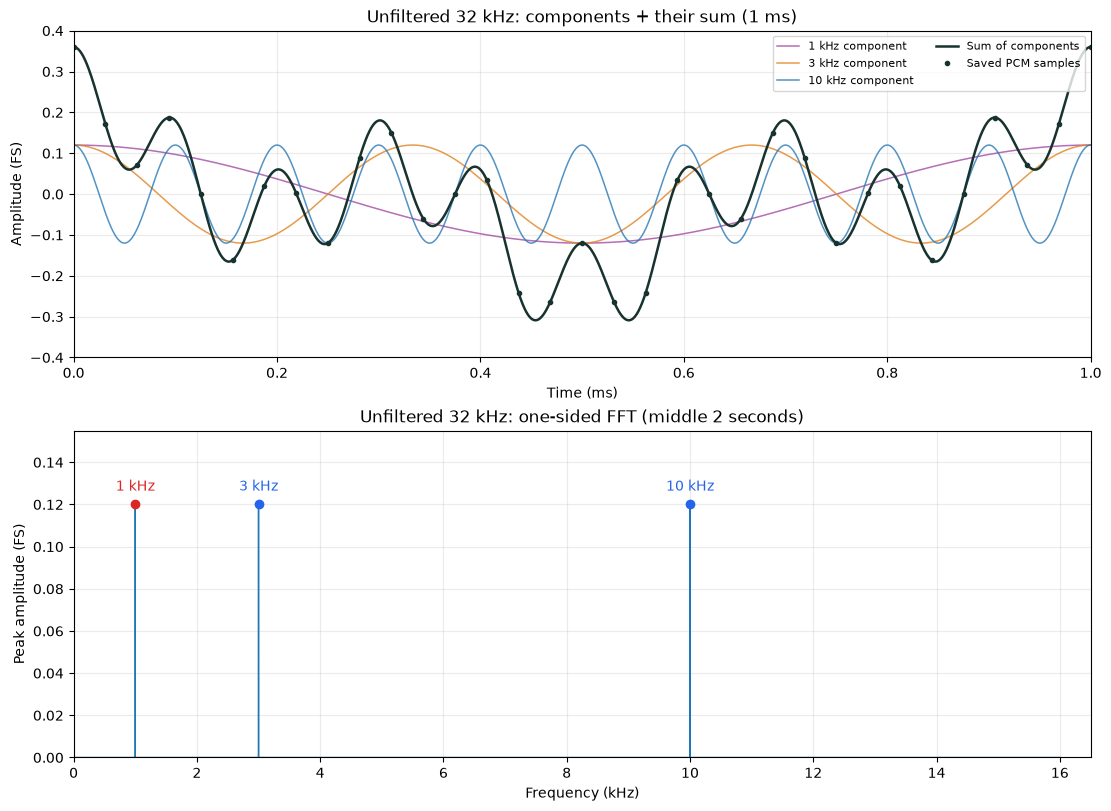

Three strongest FFT bins: [np.float64(1000.0), np.float64(3000.0), np.float64(10000.0)]
Unfiltered 1 kHz amplitude: 0.120002 FS


In [5]:
show_waveform_and_fft(unfiltered_pcm, unfiltered_rate, "Unfiltered 32 kHz",
                      (1_000, 3_000, 10_000), "notebook_unfiltered.png")

frequencies, amplitudes = one_sided_fft(unfiltered_pcm, unfiltered_rate)
print("Three strongest FFT bins:", sorted(frequencies[np.argsort(amplitudes)[-3:]]))
print(f"Unfiltered 1 kHz amplitude: {amplitude_at(unfiltered_pcm, unfiltered_rate, 1_000):.6f} FS")

## 5. Apply a low-pass filter before downsampling

The correct order is:

**64 kHz PCM → low-pass filter → keep alternate samples → 32 kHz PCM.**

We design a **129-tap, Hamming-windowed sinc FIR filter** using NumPy. An FIR output is a weighted sum of recent input samples:

$$
z[n]=\sum_{k=0}^{128}h[k]x[n-k]
$$

The ideal low-pass impulse response is truncated and tapered with a Hamming window. Coefficients are normalized to unity DC gain. We choose a **14 kHz nominal cutoff**, below the new 16 kHz Nyquist limit, to leave room for a finite transition band. This is an illustrative design, not a universal production filter specification.

A finite filter attenuates unwanted components; it does not remove them perfectly. We measure its response at the test frequencies and across the new stopband.

The symmetric FIR has a group delay of $(129-1)/(2\times64000)=1$ ms. We use a **causal** convolution rather than a zero-phase offline filter so that the processing order resembles firmware.

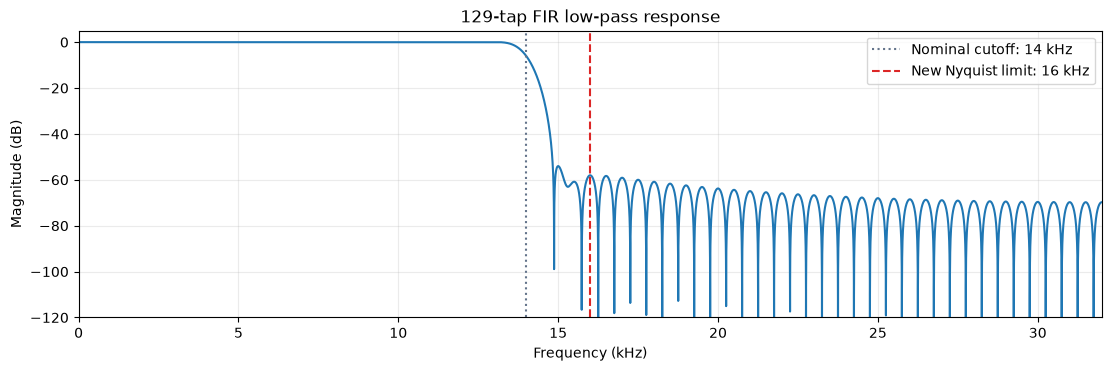

Filter gain at 3 kHz: -0.00 dB
Filter gain at 10 kHz: -0.00 dB
Filter gain at 31 kHz: -69.74 dB
Worst response over 16–32 kHz: -58.03 dB
Group delay: 1.000 ms


In [6]:
NUM_TAPS = 129
CUTOFF_HZ = 14_000
n = np.arange(NUM_TAPS)
center = (NUM_TAPS - 1) / 2

# np.sinc(u) = sin(pi*u) / (pi*u), including its limit at u=0.
h = (2 * CUTOFF_HZ / FS_IN) * np.sinc(
    2 * CUTOFF_HZ / FS_IN * (n - center)
)
h *= np.hamming(NUM_TAPS)
h /= np.sum(h)

response_hz = np.fft.rfftfreq(65_536, d=1 / FS_IN)
response = np.fft.rfft(h, n=65_536)
response_db = 20 * np.log10(np.maximum(np.abs(response), 1e-12))

fig, ax = plt.subplots(figsize=(11, 3.6), constrained_layout=True)
ax.plot(response_hz / 1000, response_db)
ax.axvline(14, color="#64748b", linestyle=":", label="Nominal cutoff: 14 kHz")
ax.axvline(16, color="#dc2626", linestyle="--", label="New Nyquist limit: 16 kHz")
ax.set(title="129-tap FIR low-pass response",
       xlabel="Frequency (kHz)", ylabel="Magnitude (dB)",
       xlim=(0, 32), ylim=(-120, 5))
ax.grid(alpha=0.25)
ax.legend()
fig.savefig(OUT / "notebook_filter_response.png", dpi=160)
plt.show()

filter_gains_db = {}
for frequency_hz in TONES_HZ:
    gain = abs(np.sum(h * np.exp(-2j * np.pi * frequency_hz * n / FS_IN)))
    filter_gains_db[str(frequency_hz)] = float(20 * np.log10(max(gain, 1e-12)))
    print(f"Filter gain at {frequency_hz / 1000:g} kHz: {filter_gains_db[str(frequency_hz)]:.2f} dB")
stopband = response_hz >= FS_OUT / 2
print(f"Worst response over 16–32 kHz: {np.max(response_db[stopband]):.2f} dB")
print(f"Group delay: {center / FS_IN * 1000:.3f} ms")

In [7]:
# 'full' convolution is causal; keep a fixed four-second recording.
# Startup and end effects are excluded from the middle-two-second FFT.
filtered_64k = np.convolve(original_pcm.astype(np.float64) / 32767, h, mode="full")
filtered_64k = filtered_64k[:len(original_pcm)]

filtered_32k = filtered_64k[::2]  # Discard samples only after filtering.
assert np.max(np.abs(filtered_32k)) < 1.0
filtered_pcm = np.rint(filtered_32k * 32767).astype(np.int16)

save_pcm16(OUT / "after_32khz_filtered.wav", filtered_pcm, FS_OUT)
filtered_pcm, filtered_rate = load_pcm16(OUT / "after_32khz_filtered.wav")

print("Listen again: the unwanted 1 kHz tone is now strongly attenuated.")
listen(filtered_pcm, filtered_rate)

Listen again: the unwanted 1 kHz tone is now strongly attenuated.


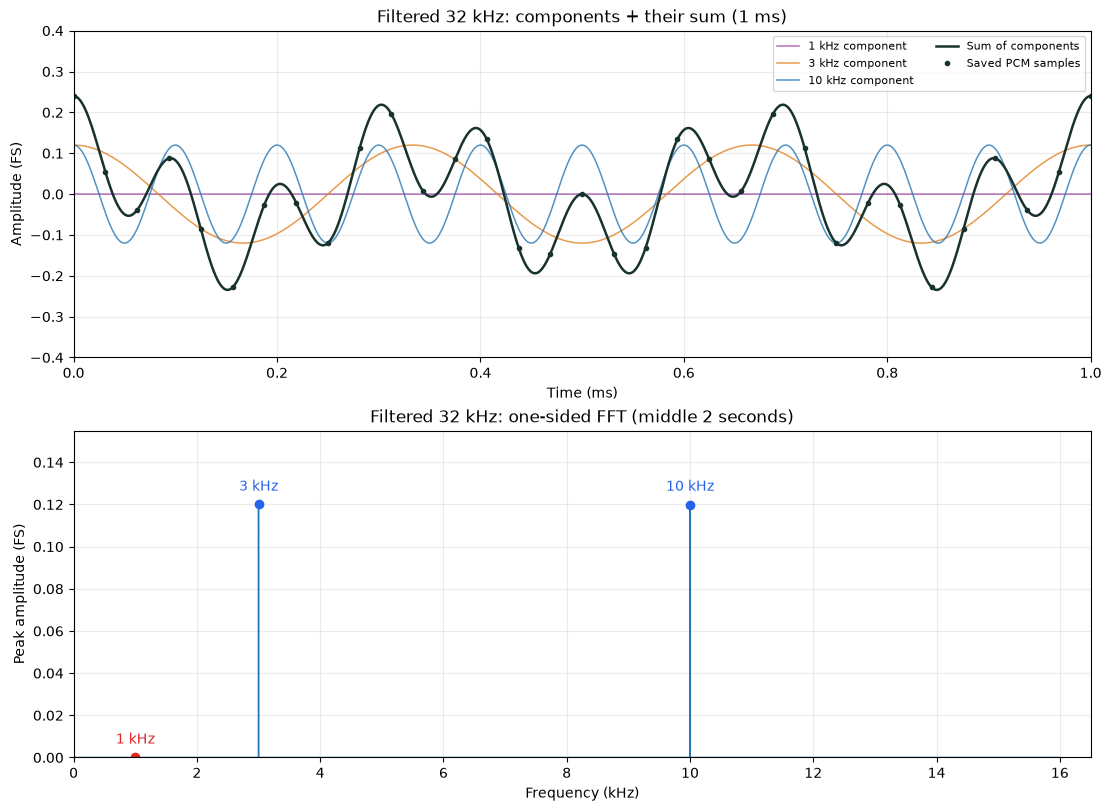

Unfiltered 1 kHz: 0.12000225 FS
Filtered 1 kHz:   0.00004093 FS
Measured alias reduction: 69.34 dB


In [8]:
show_waveform_and_fft(filtered_pcm, filtered_rate, "Filtered 32 kHz",
                      (1_000, 3_000, 10_000), "notebook_filtered.png")

original_1k = amplitude_at(original_pcm, original_rate, 1_000)
unfiltered_1k = amplitude_at(unfiltered_pcm, unfiltered_rate, 1_000)
filtered_1k = amplitude_at(filtered_pcm, filtered_rate, 1_000)
suppression_db = 20 * np.log10(unfiltered_1k / max(filtered_1k, 1e-12))

print(f"Unfiltered 1 kHz: {unfiltered_1k:.8f} FS")
print(f"Filtered 1 kHz:   {filtered_1k:.8f} FS")
print(f"Measured alias reduction: {suppression_db:.2f} dB")

## 6. Conclusion

Playing the retained samples at the correct new rate preserves duration and in-band pitch. It does **not** preserve every frequency originally present.

- The original 64 kHz PCM contains 3, 10 and 31 kHz.
- Unfiltered downsampling to 32 kHz maps 31 kHz to 1 kHz.
- Low-pass filtering **before** downsampling strongly attenuates that unwanted alias while retaining the 3 and 10 kHz components.
- Filtering after aliasing cannot distinguish the folded 1 kHz tone from a genuine 1 kHz input using frequency selection alone.

The following table and checks use measured amplitudes from the saved PCM16 files. Small residual components can remain because the FIR is finite and PCM is quantized.

In [9]:
records = [
    ("Original", original_pcm, original_rate),
    ("Unfiltered downsample", unfiltered_pcm, unfiltered_rate),
    ("Filtered downsample", filtered_pcm, filtered_rate),
]
rows = []
for name, pcm, rate in records:
    rows.append(
        f"| {name} | {rate / 1000:g} | {len(pcm) / rate:.1f} | "
        f"{amplitude_at(pcm, rate, 1_000):.8f} | "
        f"{amplitude_at(pcm, rate, 3_000):.6f} | "
        f"{amplitude_at(pcm, rate, 10_000):.6f} |"
    )
display(Markdown(
    "| Path | Rate (kHz) | Duration (s) | 1 kHz (FS) | 3 kHz (FS) | 10 kHz (FS) |\n"
    "|---|---:|---:|---:|---:|---:|\n" + "\n".join(rows)
))
display(Markdown(f"**Measured reduction of the 1 kHz alias: {suppression_db:.2f} dB.**"))

assert original_1k < 1e-4
assert unfiltered_1k > 0.119
assert suppression_db > 50
for frequency_hz in (3_000, 10_000):
    assert abs(amplitude_at(filtered_pcm, filtered_rate, frequency_hz) - AMPLITUDE) < 0.001
for _, pcm, rate in records:
    assert len(pcm) / rate == DURATION
    assert np.max(np.abs(pcm.astype(np.int32))) < 32767

assert original_rate == FS_IN
assert unfiltered_rate == filtered_rate == FS_OUT
for pcm, rate, expected_peaks in (
    (original_pcm, original_rate, [3_000, 10_000, 31_000]),
    (unfiltered_pcm, unfiltered_rate, [1_000, 3_000, 10_000]),
    (filtered_pcm, filtered_rate, [3_000, 10_000]),
):
    frequencies, amplitudes = one_sided_fft(pcm, rate)
    strongest = sorted(frequencies[np.argsort(amplitudes)[-len(expected_peaks):]])
    assert strongest == expected_peaks

results = {
    "input_rate_hz": FS_IN,
    "output_rate_hz": FS_OUT,
    "tones_hz": list(TONES_HZ),
    "fir_taps": NUM_TAPS,
    "nominal_cutoff_hz": CUTOFF_HZ,
    "group_delay_ms": center / FS_IN * 1000,
    "filter_gains_db": filter_gains_db,
    "original_1khz_amplitude_fs": original_1k,
    "unfiltered_1khz_amplitude_fs": unfiltered_1k,
    "filtered_1khz_amplitude_fs": filtered_1k,
    "alias_reduction_db": float(suppression_db),
}
# Publish the manifest only after all checks above pass.
notebook_path = ROOT / "code" / "01_pcm_aliasing_walkthrough.ipynb"
notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
code_source = "\n".join(
    "".join(cell["source"]) for cell in notebook["cells"] if cell["cell_type"] == "code"
)
artifact_paths = {
    "original_audio": "input/before_64khz.wav",
    "unfiltered_audio": "output/after_32khz_unfiltered.wav",
    "filtered_audio": "output/after_32khz_filtered.wav",
    "original_plot": "output/notebook_original.png",
    "unfiltered_plot": "output/notebook_unfiltered.png",
    "filtered_plot": "output/notebook_filtered.png",
    "filter_response": "output/notebook_filter_response.png",
    "original_waveform": "output/notebook_original_waveform.png",
    "unfiltered_waveform": "output/notebook_unfiltered_waveform.png",
    "filtered_waveform": "output/notebook_filtered_waveform.png",
    "original_fft": "output/notebook_original_fft.png",
    "unfiltered_fft": "output/notebook_unfiltered_fft.png",
    "filtered_fft": "output/notebook_filtered_fft.png",
}
manifest = {
    "verified": True,
    "source_code_sha256": hashlib.sha256(code_source.encode("utf-8")).hexdigest(),
    "measurements": results,
    "artifacts": {
        name: {"path": path, "sha256": hashlib.sha256((ROOT / path).read_bytes()).hexdigest()}
        for name, path in artifact_paths.items()
    },
}
(OUT / "results.json").write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
print("All checks passed. Results and artifact hashes saved to output/results.json.")


| Path | Rate (kHz) | Duration (s) | 1 kHz (FS) | 3 kHz (FS) | 10 kHz (FS) |
|---|---:|---:|---:|---:|---:|
| Original | 64 | 4.0 | 0.00000041 | 0.120000 | 0.119998 |
| Unfiltered downsample | 32 | 4.0 | 0.12000225 | 0.120001 | 0.119999 |
| Filtered downsample | 32 | 4.0 | 0.00004093 | 0.119996 | 0.119939 |

**Measured reduction of the 1 kHz alias: 69.34 dB.**

All checks passed. Results and artifact hashes saved to output/results.json.


### What this means for embedded firmware

For a digital microphone, transport integrity and signal fidelity are separate concerns. DMA can deliver every retained sample correctly while a firmware downsampler introduces aliasing.

A practical design must specify the wanted bandwidth, passband error, stopband attenuation, filter delay and execution budget. A sensor's internal filter is sufficient only if its output is already limited appropriately for the **new** sample rate.

This notebook is a desktop reference experiment. It does not benchmark a specific MCU, microphone, DMA driver or real-time implementation.

### References

- [MathWorks: downsample — filtering before sample-rate reduction](https://www.mathworks.com/help/signal/ref/downsample.html)
- [NumPy: sinc — normalized sinc definition](https://numpy.org/doc/stable/reference/generated/numpy.sinc.html)
- [SciPy: firwin — window-method FIR design and cutoff interpretation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.firwin.html)

The FIR in this notebook is implemented directly with NumPy; SciPy is not a runtime dependency.

## 7. Future Improvements — Detecting Content Above the Nyquist Limit

**Discovery question:** Before reducing the sample rate, how can firmware determine whether the PCM contains significant frequency content above the **new** Nyquist limit?

For the current **64 → 32 kHz** experiment, the limit to investigate is **16 kHz**. The original 64 kHz PCM can represent components between 16 and 32 kHz, so we can inspect that band **before** discarding samples.

### Proposed investigation

1. **Analyze the original PCM.** Compute an FFT or an averaged power spectral density across multiple audio blocks. Look for significant energy above 16 kHz.
2. **Measure how much energy is at risk.** Compare the power in the 16–32 kHz band with the total measured signal power. Investigate an absolute noise-floor threshold as well as a relative-power threshold.
3. **Test with known signals.** Use tones below and above 16 kHz, broadband noise, and short ultrasonic bursts. Compare the estimated out-of-band energy with the aliases observed after unfiltered downsampling.
4. **Evaluate the detection limits.** Study window length, spectral leakage, background noise, intermittent events, and MCU processing cost. Choose thresholds from measurements rather than treating every nonzero FFT bin as meaningful signal content.

This would produce an **out-of-band energy estimate**, not proof that aliasing is impossible. A short analyzed block may miss an event that occurs later. Detection is useful for characterization; it does not replace a properly specified anti-alias filter.

### What cannot be determined from the samples alone

The **original** and **new** Nyquist limits are different. An FFT of 64 kHz PCM can inspect frequencies up to 32 kHz; it cannot uniquely reveal analog components above that original limit if they have already aliased during acquisition.

Likewise, after reducing to 32 kHz, a 1 kHz component alone cannot tell us whether the source was a genuine 1 kHz tone or the original 31 kHz tone. We need the pre-downsampling data or additional information about the acquisition chain.

**Future deliverable:** a block-based spectral monitor, validated against known test signals, reporting estimated energy above the target Nyquist limit and its computation cost.